# Applying the Elo Rating Algorithm to Different Sports Competitions

## 1. Introduction
In competitive environments, measuring skill is not always straightforward. Wins and losses alone don’t tell the full story. Specially when opponents vary in strength.
This is where rating systems come in.

One of the most widely used systems is the Elo rating algorithm, originally developed for chess. Over time, it has been adapted and applied across many different competitive domains.

In this project, we will explore how the Elo rating system can be applied to a variety of sports and competitive environments, including:
- Chess
- MMA
- Football
- esports - Counter Strike
- Formula 1

Each of these disciplines presents unique challenges. Some are one-versus-one competitions, others are team-based, and some involve multiple competitors at the same time. This makes them ideal case studies for testing how flexible and adaptable the Elo system really is.

THe goal of this project is to understand how elo works and explore how it can be modified and extended to fit different types of competition.

## 2. Elo System Explained
The Elo rating system is a mathematical method used to estimate the skill level of players or teams in competitive environments.

Each player starts with a rating value (usually 1500), and this rating changes after every match depending on two key factors:
- the match result
- the relative strength of the opponent

The core idea behind Elo is simple:
**rating changes depend on how expected or unexpected a result is**.

In practice, this means:
- If a strong player defeats a weaker opponent, their rating increases only slightly, because the result was expected.
- If a weaker player defeats a stronger opponent, their rating increases significantly, because the result was unexpected.
- If the outcome matches expectations, the rating change remains small.

As more matches are played, the rating gradually becomes a more accurate representation of a player’s true skill level.

The Elo system is widely used across different domains, including:
- chess primearly
- football analytics
- esports ranking 
- onlnie games
- matchmaking systems 



In this project, we will explore how this general ranking method can be adapted to different types of competitions, including combat sports, team sports, motorsports, and esports.

| Sport | Type |
| ------ | ------ |
| Chess | 1v1 |
| MMA | 1v1 |
| Football | Team |
| F1 | multi-player ranking |
| Counter Strike | Team |

## 3. How is elo rating calculated

There are two parts of the elo the expected score and the Rating update formulas.
the difference between these two values determines how much the rating will change.
The difference between these two values determines how much the rating will change.


### Expected Score
Before a match takes place, the Elo system calculates the expected score for each competitor. This value represents the probability that a player will win the match based on the difference in ratings.

For a player A playing against player B. We calculate the expected score using the following formula:

$$
E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}
$$

Here:
- $E_A$ is expected score or wnd probability for player A
- $R_A$ is the rating of player A
- $R_B$ is the rating of the player B

This formula converts the rating difference into a probability between 0 and 1.

- If both players have the same rating, the expected score is 0.5 meaning both players have equal chances of winning
- If player A has higher rating, the expected score will be greater than 0.5, meaning player A is favored to win.
- If player A has lower rating, the expected score will be less than 0.5, resulting in player B being mire likely to win

---
### The Logic of the "400" Scale Factor
We've explored the formula but one question raises. Why do we have this number 400, why not 100 or maybe 1000?

In the Elo formula, the denominator 400 acts as a scaling constant that determines the "width" of the probability distribution. Meaning it defines exactly how much a difference in rating points translates into a win probability.

The Elo system is based on a Logistic Distribution. The value of 400 was chosen by Arpad Elo the creator of the formula to ensure that ratings stayed within a human-readable range.

> Fun Fact: Arpad Elo was also a master-level chess player

To understand why we use this specific formula, we can look at the ratio of expected scores between Player A ($E_A$) and Player B ($E_B$). By dividing the two formulas, we get a simplified look at how much "stronger" one player is than another:

$$
E_B = \frac{1}{1 + 10^{(R_A - R_B)/400}}
$$

$$
\frac{E_A}{E_B} = 10^{(R_A - R_B)/400}
$$

Now, we plug in a rating difference of exactly 400 points $R_A - R_B = 400$:

$$
\frac{E_A}{E_B} = 10^{400/400}
$$

$$
\frac{E_A}{E_B} = 10^1 = 10
$$

What this tells us is that in the standard Elo system, a 400-point advantage means Player A is expected to be 10 times stronger than Player B. If the gap was 800 points, Player A would be 100 times stronger

> But what if we change the 400 metric?
<br>

If we lowered this number the system would become hyper sensitive, where even a 50 point lead would make a player massive favorite. 
On the other hand, raising it would "compress" the ratings, making a huge points gap look like a tiny difference in actual win probability. Essentially, the 400-point constant is the mathematical "sweet spot" that ensures rating differences feel both realistic and distinguishable to human observers.

> Why this matter for this project
<br>

In this project, we retain the 400 constant across all sports. This allows us to have a universal language of skill:
a 200-point lead in MMA means exactly the same thing mathematically as a 200-point lead in Formula 1—it represents a specific, measurable probability of victory 76%.By keeping the scale factor constant at 400 and only adjusting the K-factor, we isolate how fast ratings change from Skill Gap (what the ratings actually mean).

---

### Update Rating Formula
After the match result is known, the rating of each competitor is updated using the following formula:
$$
R'_A = R_A + K(S_A - E_A)
$$

Here:
- $R'_A$ is the new rating of player A
- $R_A$ is the old rating of player A
- $S_A$ is the actual score of player A
- $E_A$ is the expected score of player A
- K is a constant called  K-factor

#### The K-factor
The K-factor determines how quickly ratings change overtime . 
A larger K value means rating change faster, where a smaller K value makes ratings nore stable. Different competitions and organisations set different value of K. 

| K-value | Description |
| ----------- | ----------- |
| 10 | Very stable |
| 20 - 40 | Moderate rating change |
| 80 or more | Rating changes very fast |

As more matches are played, the system gradually improves its estimation, and player ratings begin to closely reflect their true skill level.
This is why having a larger dataset is important for producing reliable results.


> Why K-factors can be a problem>
<br>

If we set K too high for a sport with many matches (like Chess), the leaderboard would constantly shuffle randomly. If we set it too low for a sport with few matches (like MMA), a fighter could win five fights in a row and still be ranked at the bottom. 

1. Match Frequency: In MMA, a fighter might only compete twice a year. Every data point is precious. Therefore, we use a higher K to ensure the rating captures their current form.
2. Sample Size: In sports with hundreds of games, we have "statistical confidence." We can afford a low K because we know the sheer volume of matches will eventually lead the player to their true rating.

<br>

> **How do we choose K in this project?**


In this research, the value of K will depend on the nature of each sport.
Sports with many matches (like chess or football) use lower K values for stability, while sports with fewer matches (like MMA) require higher K values so that each result has a stronger impact.

## 4. Pro's and Cons of the rating system

### Advantages 
1. **Simple and efficient**
The Elo system is extremely "light." It only requires the current ratings and the latest match result to update, making it ideal for large historical datasets.

2. **Dynamic Skill estimation**:
Unlike a simple win-loss percentage, Elo is "time-aware." It recognizes that a player’s skill changes over time, rewarding recent improvements more than past failures.

3. **Self-correcting Mechanism**:
If a player is underrated, they will win more points than they lose, naturally "pulling" their rating toward their true skill level over time.

4. **Wide Applicability**:
As shown in this project, the core logic of "Expected vs. Actual" can be exported to almost any competitive field.

### Disadvantages
1. **Designed for two-player competition**:
Standard Elo is designed for 1v1 "Win/Loss" scenarios. It struggles with multi-competitor environments (like Formula 1) without significant mathematical restructuring.

2. **Contextual Blindness:**
Limited context awareness meaning we base the matches soley on the matches outcome. Meaning elo treats a "Split Decision" win in MMA—where the fight was almost equal—the same as a "First Round Knockout." It ignores the margin of victory, which is often a key indicator of future performance.

3. **Sensitive K-factor**:
As discussed in the previous section, an incorrect K-factor can lead to a "noisy" leaderboard or one that is too stagnant to reflect reality.

4. **Initial Rating Bias** - New entries start at a default value like 1500. Until they have played enough matches to reach statistical convergence, their rating is an unreliable predictor of their skill.

### Possible improvement
Here's the question that arises:
> Can additional match information improve the accuracy of the Elo system?

In its pure form, Elo only looks at the scoreboard. However, in modern sports analytics, the way a win happens is often as important as the win itself.

For example:
- In football, a 4–0 win may indicate greater dominance than a 1–0 win
- In MMA, a knockout or submission may reflect clearer superiority than a decision
- In Formula 1, finishing positions across the grid provide more information than a simple win/loss outcome
- In this project, we will explore simple modifications to the Elo system that incorporate such factors.


##### The Margin to Victory Modifier
To address the Contextual Blindness mentioned above, this project introduces a K-multiplier (m). We modify the update formula as follows:

$$
R'_A = R_A + (K \cdot m)(S_A - E_A)
$$

By adjusting the multiplier m we can add weight different outcomes.
For example:

- **In MMA**: A Knockout (KO) provides "stronger evidence" of superiority than a Judge's Decision. We can set $m=1.2$ for KOs to accelerate the rating gain.

- **In Football**:
In a team sport like football, a 1–0 win might be a lucky break, but a 4–0 win is a statistical statement of dominance. We can implement a rule where if the Goal Difference > 3, we apply a multiplier to reward the winning team for their offensive efficiency.

- **In Esports - Counter-Strike**:
Since professional CS is often played in a "Best of 3" maps format, a 2–0 victory shows a team mastered their opponent's strategy entirely, whereas a 2–1 victory suggests a closely contested match. A multiplier can be used here as well.

By implementing these specific modifications, we aim to transform Elo from a simple "Chess tool" into a specialized "Sports Engine."

## 5. Implementing the Elo Rating System in Python

### Code Imports

In [2]:
import math
import pandas as pd 
import matplotlib.pyplot as plt

---

In [3]:
def expected_score(player_a, player_b):
    return 1/(1 + 10**((player_b - player_a)/400))

In [4]:
# Example calculations of expected score
# Player A (1500) vs much weaker player (1060) -> very high expected score
print(expected_score(1500, 1060))

# Two players with very similar ratings -> expected score close to 0.5
print(expected_score(1330,1310))

# Player A is weaker than Player B -> expected score below 0.5
print(expected_score(1400, 1500))

0.9264124438824264
0.5287505638922686
0.35993500019711494


In [5]:
def update_rating(prev_rating, expected_score_value, actual_score, k):
    """
    This is the function that updates a player's Elo rating after a match.
    Parameters:
        - prev_rating: the player's rating before the match
        - expected_score_value: the expected result calculated from Elo
        - actual_score: the real match result
        - k: the K-factor, which controls how much the rating changes
    
    actual_score:
    1   = win
    0.5 = draw
    0   = loss
    """
    return prev_rating + k*(actual_score - expected_score_value)

- **Player A wins against a weaker oponent** <br>
Since this result is expected, the rating increase should be small.

In [6]:
expected_score_value = expected_score(1500, 1060)
new_rating = update_rating(1500, expected_score_value, 1, 20)
print(new_rating)


1501.4717511223514


- **Player A looses against a weaker oponent** <br>
This is an unexpected result, so the rating decrease should be larger.

In [7]:
expected_score_value = expected_score(1500, 1060)
new_rating = update_rating(1500, expected_score_value, 0, 20)
print(new_rating)


1481.4717511223514


- **Player A finishes in a draw against a weaker oponent** <br>
A draw against a weaker player is worse than expected, so Player A should still lose some rating points.

In [8]:
expected_score_value = expected_score(1500, 1060)
new_rating = update_rating(1500, expected_score_value, 0.5, 20)
print(new_rating)


1491.4717511223514


- **Processing a full match**

In [9]:
def full_match(player_a, player_b, result_a, k=20):
    """
    This function processes a full match between two players.
    Instead of updating only one player, it updates both ratings.
    Parameters:
      - player_a: rating of Player A before the match
      - player_b: rating of Player B before the match
      - result_a: result from Player A's perspective
        (1 = win, 0.5 = draw, 0 = loss)
      - k: K-factor used in the Elo update
    """

    expected_score_a = expected_score(player_a, player_b)
    expected_score_b = expected_score(player_b, player_a)

    result_b = 1 - result_a

    new_rating_a = update_rating(player_a, expected_score_a, result_a, k)
    new_rating_b = update_rating(player_b, expected_score_b, result_b, k)

    return new_rating_a, new_rating_b

In [10]:
# Player A wins against Player B
a, b = full_match(1500, 1060, 1)

print(f"Player A's new rating: {a}")
print(f"Player B's new rating: {b}")

Player A's new rating: 1501.4717511223514
Player B's new rating: 1058.5282488776486


## 6. Applying Elo Across Different Sports 

### 6.1 Chess
Chess represents the most established real-world implementation of the Elo rating. It is the official rating for players who compete in rated tournaments worldwide.

According to the Interanational Chess federation website the K-factor is calculated the following way:

 Category | K-Value | Mathematical Justufication
| ----------- | ----------- | ----------- |
| **New Players** (First 30 games) | 40 | The system has high uncertainty and needs to find the player's true skill level quickly. |
| **Junior Players** (Under 18) | 40 | Younger players improve at a non-linear rate; the model must remain sensitive to rapid skill spikes. The K-value is 40 as long as their rating remains under 2300|
| **Standard Players** (Rating < 2400) | 20 | A balance between reflecting recent form and maintaining long-term ranking integrity. |
| **Elite Players** (Rating > 2400) | 10 | At the Grandmaster level, skill is highly stable. Small K prevents minor "bad days" from causing massive ranking swings. |

> Chess.com typically use a static K-value of 16 for established players, showing that different organizations prioritize different levels of rating responsiveness.




Meaning when the system has less information about a player's strength, ratings should adjust more quickly. As more games are played and the player's skill becomes better estimated, the rating changes become smaller and more stable.

In modern chess, Elo ratings are used not only for ranking players but also for tournament seeding, title qualification, and performance analysis.

The rating is also a requirement for professional titles and milestones. As stated in wikipedia:

| Rating | Classification |
| ----- | ----- |
| 2600+ | Super Grandmasters |
| 2500–2599 | Grandmasters |
| 2400–2499 | International Masters |
| 2300–2399 | FIDE Masters |
| 2200–2299 | Candidate Masters |
| 2000–2199 | Experts |
| 1800–1999 | Class A |
| 1600–1799	| Class B |
| 1400–1599 | Class C |
| 1200–1399 | Class D |
| 1000–1199 | Class E |
| Below 1000 | Novices |

From a coding perspective, Chess is the most "direct" application of the logic found in Section 5. Because the game is strictly 1 versus 1 and outcomes are limited to a win (1), draw (0.5), or loss (0), our **full_match()** function can be used without any modifications. 

Each game result is represented numerically as:
- 1 for a win
- 0.5 for a draw
- 0 for a loss

Exactly the way we've implemented above.

Chess acts as our "Control Group": if our Python implementation works here, we know the core logic is sound before we begin adding the complex "Margin of Victory" multipliers required for MMA and other sports.

### 6.2 MMA
MMA or Mixed Martial Arts is another sport where the Elo rating model can be applied naturally because fights are conducted as one-versus-one competitions between two athletes. Each fight produces a clear outcome: one fighter wins and the other loses, while draws are rare but still possible.

#### K-Factor
Unlike chess, professional MMA fighters compete far less frequently. A chess player may play hundreds of rated games over time, while a professional fighter may compete only 2–3 times per year.
Because of this smaller number of matches, rating adjustments need to react more strongly to individual results.
For this reason, in this project a higher K-factor is used for MMA compared to chess. A value of $K = 60$ seems like a good number.
A larger K-value allows the system to adjust quickly when new information (like a major upset) becomes available.
On the other hand it becomes very sensitive. Ensuring that a single victory over a high-ranked opponent for example has a massive impact, reflecting the high stakes of the fights.


The higher K-factor reflects the idea that each fight carries more informational value about a fighter's ability. With fewer matches available, the rating must update more aggressively in order to reflect changes in performance.

This approach allows the ranking system to respond quickly when a fighter defeats a stronger opponent or suffers an unexpected loss.

Every fighter should start with elo 1500 close to the chess. As the rank will update fairly quickly because of the huge top K value we've set.

Every fight result can be represented numerically with the same structure we've implemented earlier 
- 1 for a win
- 0.5 for a draw or no contest
- 0 for a loss

#### Victory Modifier
We'll also introduce a modification as the one we discussed in the previous sections. 
It would alllow us to take into consideration the outcome of the fihgt. If the mach has ended with a more decisive outcome, such as KO or submission. We treat them as stronger evidence of a fighter's superiority and therefore produce larger rating changes. 

Again this is the formula we are going to use:
$$
R'_A = R_A + (K \cdot m)(S_A - E_A)
$$
We'll implement this by multiplying the base k-factor by a method specific modifier.

1. KO/TKO (m = 1.2) - Definitive Evidence
A knockout is the most objective result in MMA. It represents a total physical shutdown of the opponent, leaving zero room for judging error.
Mathematically, we increase K by 20% to signal to the model that this result is high-quality data and should be prioritized

2. Submission (m = 1.15) - Technical Dominance
Similar to a KO, a submission represents a "finish." However, statistically, submissions can sometimes involve more "scrambling" or situational transitions than a clean knockout. We use 1.15 to reward the finish while acknowledging it as slightly less "binary" than a physical knockout in terms of pure power dominance.

3. Unanimous Decision (m = 1.1) Consistent Outperformance
When all three judges agree that Fighter A won, it shows a clear trend across 15 to 25 minutes of combat. The 10% bonus reflects that while the opponent wasn't finished, the winner was demonstrably better across every round.

4. Split Decision / Draw (m = 1)
A Split Decision means at least one professional judge thought the other person won. Here the skill gap is so narrow that experts couldn't agree, so we keep m at baseline. We don't want the system to overreact to a result that was basically a coin flip.

It is important to note that these modifiers are kept relatively small (between 1.0 and 1.2). If we used a multiplier of 2.0, a single lucky knockout could catapult a mediocre fighter to the top of the world rankings. By keeping m conservative, we ensure that long-term consistency still outweighs one-off lucky shots, preserving the integrity of the leaderboard.

#### Inactivity Problem
Standard Elo assumes that a competitor’s skill remains unchanged during periods of inactivity.
This assumption is reasonable in environments such as chess, where players compete frequently and skill changes are often reflected through regular results. 
In MMA, however, long layoffs can significantly affect performance.

A fighter who has not competed for a long period may experience several disadvantages:
- loss of competitive sharpness, often referred to as ring rust
- decline due to aging
- reduced performance after injuries or recovery periods
- changes in training environment or motivation

Because of this, keeping an inactive fighter’s rating unchanged may overestimate their current ability. It can also create an unrealistic leaderboard in which retired, injured, or inactive fighters remain near the top despite no longer competing at that level.

To address this issue, we introduce a rating decay mechanism. If a fighter has been inactive for more than 500 days, their rating is reduced by 10% before their next update or before generating the rankings. This creates a more active and realistic leaderboard and better reflects the uncertainty around a fighter’s current level after a long absence.

In [69]:
# The data set used is from Kaggle: https://www.kaggle.com/datasets/neelagiriaditya/ufc-datasets-1994-2025/data?select=fighter_details.csv
# The data set was processed and cleaned by me in a separate notebook (it is not included in this repository as it is outside the scope of this project)
# The final version is saved as "final_ufc_data.csv". It contains all the relevant information about the fights, including the date, fighters' names, and fight outcomes.

# Load the UFC fights dataset and preview the first few rows

ufc_data = pd.read_csv("final_ufc_data.csv")

ufc_data.head()

,date,event_id,event_name,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,referee,fighter_1,fighter_1_id,fighter_2,fighter_2_id,winner,winner_id,result,fighter_1_score,fighter_2_score
0,1994-03-11,a6a9ab5a824e8f66,UFC 2: No Way Out,"Denver, Colorado, USA",00835554f95fa911,2 tournament,True,KO/TKO,1,77,...,John McCarthy,Royce Gracie,429e7d3725852ce9,Patrick Smith,46c8ec317aff28ac,Royce Gracie,429e7d3725852ce9,win,1.0,0.0
1,1994-03-11,a6a9ab5a824e8f66,UFC 2: No Way Out,"Denver, Colorado, USA",17ee4caf06981b81,open weight,False,SUB,1,591,...,John McCarthy,Remco Pardoel,749685d24e2cac50,Alberta Cerra Leon,6e02c318762f52f1,Remco Pardoel,749685d24e2cac50,win,1.0,0.0
2,1994-03-11,a6a9ab5a824e8f66,UFC 2: No Way Out,"Denver, Colorado, USA",3b020d4914b44fc8,open weight,False,KO/TKO,1,170,...,John McCarthy,Orlando Wiet,a6c2f5381d575920,Robert Lucarelli,96087e90d900f0ef,Orlando Wiet,a6c2f5381d575920,win,1.0,0.0
3,1994-03-11,a6a9ab5a824e8f66,UFC 2: No Way Out,"Denver, Colorado, USA",4acab67848e78327,open weight,False,SUB,1,20,...,John McCarthy,Scott Morris,be9d259be012e8a4,Sean Daugherty,a683f9ddb70aa4bd,Scott Morris,be9d259be012e8a4,win,1.0,0.0
4,1994-03-11,a6a9ab5a824e8f66,UFC 2: No Way Out,"Denver, Colorado, USA",4b9ae533ccb3fcdf,open weight,False,SUB,1,58,...,John McCarthy,Patrick Smith,46c8ec317aff28ac,Ray Wizard,ea0ad155451ed1f5,Patrick Smith,46c8ec317aff28ac,win,1.0,0.0


In [70]:
print("Shape of the dataset:", ufc_data.shape)
print("Columns in the dataset:", ufc_data.columns)

Shape of the dataset: (8337, 21)
Columns in the dataset: Index(['date', 'event_id', 'event_name', 'location', 'fight_id', 'division',
       'title_fight', 'method', 'finish_round', 'match_time_sec',
       'total_rounds', 'referee', 'fighter_1', 'fighter_1_id', 'fighter_2',
       'fighter_2_id', 'winner', 'winner_id', 'result', 'fighter_1_score',
       'fighter_2_score'],
      dtype='str')


In [71]:
print(df_new.columns)

Index(['date', 'event_id', 'event_name', 'location', 'fight_id', 'division',
       'title_fight', 'method', 'finish_round', 'match_time_sec',
       'total_rounds', 'referee', 'fighter_1', 'fighter_1_id', 'fighter_2',
       'fighter_2_id', 'winner', 'winner_id', 'result', 'fighter_1_score',
       'fighter_2_score'],
      dtype='str')


In [72]:

k = 60
starting_elo = 1000
inactivity_threshold = 500  # days
inactivity_decay = 0.10 # 10% decay

# Convert dates before sorting
ufc_data["date"] = pd.to_datetime(ufc_data["date"])


# Reverse the dataset so that fights are processed from oldest to newest.
# Sort fights from oldest to newest so Elo updates happen in the correct order
ufc_data = ufc_data.sort_values("date").reset_index(drop=True)


# Dictionary that stores the current Elo rating of each fighter
ratings = {}
last_fight_date = {}   
elo_history = []

def modifier(method):
    """
    This function adjusts the K-factor based on the method of victory.
    The main idea is that the more decisive the victory, the more the ratings should change.
    """
    # In this new database we also have Doctor Stoppage, which is essentially a TKO, so we will treat it the same as KO/TKO.
    if method == "KO/TKO" or method == "TKO - Doctor's Stoppage":
        return 1.2
    elif method == "Submission":
        return 1.15
    elif method == "Decision - Unanimous":
        return 1.1
    else:
        return 1.0

def apply_inactivity_decay(fighter, fight_date):
    """
    Apply rating decay if the fighter has been inactive for more than
    the chosen threshold.

    If inactivity exceeds 500 days, reduce rating by 10%.
    """
    if fighter in last_fight_date:
        days_inactive = (fight_date - last_fight_date[fighter]).days

        if days_inactive > inactivity_threshold:
            ratings[fighter] *= (1 - inactivity_decay)

        return days_inactive

    return 0


# loop through every fight
for i, row in ufc_data.iterrows():
    fighter_a = row["fighter_1"]
    fighter_b = row["fighter_2"]
    result = row["result"]
    method = row["method"]
    fight_date = row["date"]
    winner = row["winner"]


    # Skip rows with missing fighter names
    if pd.isna(fighter_a) or pd.isna(fighter_b):
        continue

    # If the fighter is not in the ratings dictionary, initialize their rating to the starting Elo
    if fighter_a not in ratings:
        ratings[fighter_a] = starting_elo
    
    if fighter_b not in ratings:
        ratings[fighter_b] = starting_elo

    # Apply inactivity decay before the fight
    days_inactive_a = apply_inactivity_decay(fighter_a, fight_date)
    days_inactive_b = apply_inactivity_decay(fighter_b, fight_date)


    # We store both fighters ratings before the fight.
    rating_a_before = ratings[fighter_a]
    rating_b_before = ratings[fighter_b]

    # Calculate expected scores for both fighters
    expected_a = expected_score(rating_a_before, rating_b_before)
    expected_b = expected_score(rating_b_before, rating_a_before)

    # Determine actual scores using the winner column
    if result == "draw":
        score_a = 0.5
        score_b = 0.5
    elif pd.notna(winner):
        if winner == fighter_a:
            score_a = 1
            score_b = 0
        elif winner == fighter_b:
            score_a = 0
            score_b = 1
        else:
            continue
    else:
        continue


    # Adjust the K-factor depending on the method of victory
    current_k = k * modifier(method)

    # Update ratings for both fighters
    rating_a_after = rating_a_before + current_k * (score_a - expected_a)
    rating_b_after = rating_b_before + current_k * (score_b - expected_b)

    # Save the updated ratings back into the ratings dictionary
    ratings[fighter_a] = rating_a_after
    ratings[fighter_b] = rating_b_after

    # Update last fight dates
    last_fight_date[fighter_a] = fight_date
    last_fight_date[fighter_b] = fight_date

    elo_history.append({
        "date": fight_date,
        "fighter_a": fighter_a,
        "fighter_b": fighter_b,
        "winner": winner,
        "result": result,
        "method": method,
        "days_inactive_a": days_inactive_a,
        "days_inactive_b": days_inactive_b,        
        "k_used": current_k,
        "fighter_a_before": rating_a_before,
        "fighter_b_before": rating_b_before,
        "expected_a": expected_a,
        "expected_b": expected_b,
        "fighter_a_after": rating_a_after,
        "fighter_b_after": rating_b_after
    })

# Converth the rating history into a dataframe.
elo_df = pd.DataFrame(elo_history).round(2)


print(elo_df.head(5))

        date      fighter_a        fighter_b         winner result  method  \
0 1994-03-11   Royce Gracie    Patrick Smith   Royce Gracie    win  KO/TKO   
1 1994-03-11   Royce Gracie  Minoki Ichihara   Royce Gracie    win     SUB   
2 1994-03-11  Frank Hamaker  Thaddeus Luster  Frank Hamaker    win     SUB   
3 1994-03-11  Johnny Rhodes    David Levicki  Johnny Rhodes    win  KO/TKO   
4 1994-03-11  Jason DeLucia      Scott Baker  Jason DeLucia    win     SUB   

   days_inactive_a  days_inactive_b  k_used  fighter_a_before  \
0                0                0    72.0            1000.0   
1                0                0    60.0            1036.0   
2                0                0    60.0            1000.0   
3                0                0    72.0            1000.0   
4                0                0    60.0            1000.0   

   fighter_b_before  expected_a  expected_b  fighter_a_after  fighter_b_after  
0            1000.0        0.50        0.50           1036.0

/var/folders/yz/kp7jv1xn0ln18n13bdyc3kmr0000gn/T/ipykernel_10457/2329774912.py:138: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  elo_df = pd.DataFrame(elo_history).round(2)


In [73]:
top_fighters = pd.DataFrame(ratings.items(), columns=["fighter", "elo"])
top_fighters = top_fighters.sort_values("elo", ascending=False).round(2)

print(top_fighters.head(20))

                    fighter      elo
1437        Islam Makhachev  1344.31
1507        Francis Ngannou  1330.46
1742      Merab Dvalishvili  1314.30
932            Max Holloway  1309.13
2104           Ilia Topuria  1301.13
2054        Khamzat Chimaev  1299.72
1773       Magomed Ankalaev  1293.80
1551         Belal Muhammad  1288.34
1118           Amanda Nunes  1275.56
804      Demetrious Johnson  1275.35
1509   Valentina Shevchenko  1271.78
925     Khabib Nurmagomedov  1270.94
2100      Dricus Du Plessis  1267.26
1951             Ciryl Gane  1264.23
2226   Jack Della Maddalena  1263.21
1081         Daniel Cormier  1260.87
2098     Nassourdine Imavov  1259.47
1632      Alexandre Pantoja  1257.37
1906          Movsar Evloev  1256.91
1612  Alexander Volkanovski  1249.45


In [74]:
print(ufc_data["result"].value_counts())
print(ufc_data["method"].value_counts())

result
win     5291
loss    2899
draw     147
Name: count, dtype: int64
method
U-DEC                      2991
KO/TKO                     2621
SUB                        1619
S-DEC                       800
TKO - DOCTOR'S STOPPAGE      98
M-DEC                        95
OVERTURNED                   58
COULD NOT CONTINUE           30
DQ                           23
OTHER                         2
Name: count, dtype: int64


In [75]:
# Let's see the top 20 fighters by their final Elo ratings
top_fighters = pd.DataFrame(ratings.items(), columns=["fighter", "elo"])
top_fighters = top_fighters.sort_values("elo", ascending=False).round(2)

print(top_fighters.head(20))

                    fighter      elo
1437        Islam Makhachev  1344.31
1507        Francis Ngannou  1330.46
1742      Merab Dvalishvili  1314.30
932            Max Holloway  1309.13
2104           Ilia Topuria  1301.13
2054        Khamzat Chimaev  1299.72
1773       Magomed Ankalaev  1293.80
1551         Belal Muhammad  1288.34
1118           Amanda Nunes  1275.56
804      Demetrious Johnson  1275.35
1509   Valentina Shevchenko  1271.78
925     Khabib Nurmagomedov  1270.94
2100      Dricus Du Plessis  1267.26
1951             Ciryl Gane  1264.23
2226   Jack Della Maddalena  1263.21
1081         Daniel Cormier  1260.87
2098     Nassourdine Imavov  1259.47
1632      Alexandre Pantoja  1257.37
1906          Movsar Evloev  1256.91
1612  Alexander Volkanovski  1249.45


#### Jon Jones rating with 0.10% decay 

Final Elo for Jon Jones: 1133.57

Jon Jones Elo history:
         date              opponent       winner      method          outcome  \
0  2008-08-09          Andre Gusmao    Jon Jones       U-DEC              win   
1  2009-01-31        Stephan Bonnar    Jon Jones       U-DEC              win   
2  2009-07-11          Jake O'Brien    Jon Jones         SUB              win   
3  2009-12-05           Matt Hamill  Matt Hamill          DQ             loss   
4  2010-03-21          Brandon Vera    Jon Jones      KO/TKO              win   
5  2010-08-01  Vladimir Matyushenko    Jon Jones      KO/TKO              win   
6  2011-02-05            Ryan Bader    Jon Jones         SUB              win   
7  2011-03-19          Mauricio Rua    Jon Jones      KO/TKO              win   
8  2011-09-24       Quinton Jackson    Jon Jones         SUB              win   
9  2011-12-10         Lyoto Machida    Jon Jones         SUB              win   
10 2012-04-21          Rashad Evans    Jon Jones    

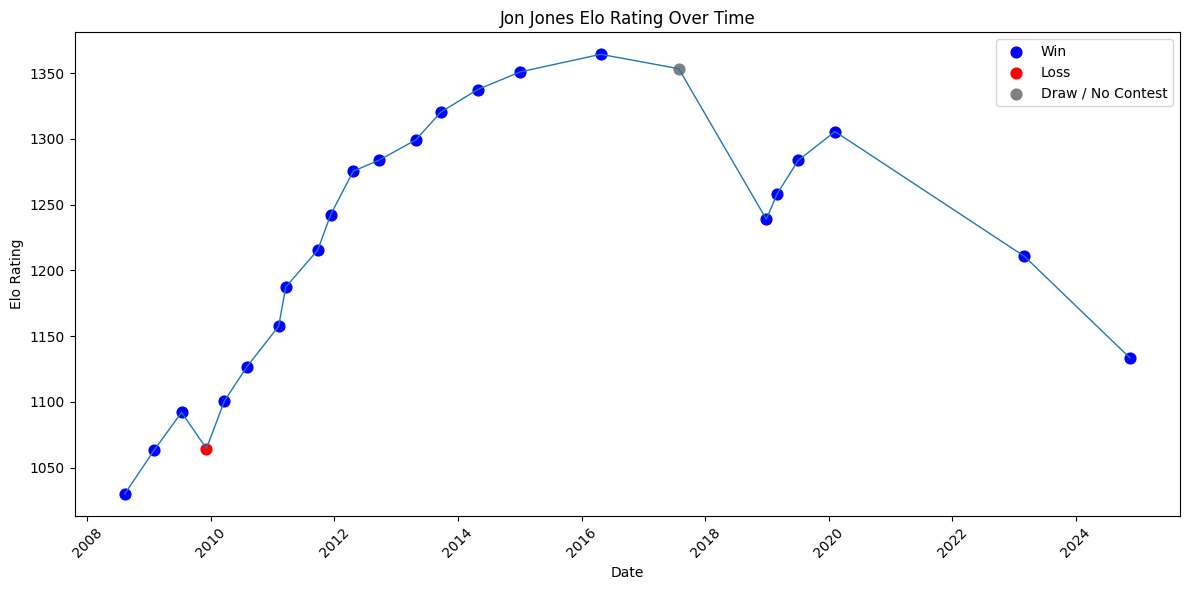

In [76]:


fighter_name = "Jon Jones"


print(f"Final Elo for {fighter_name}: {round(ratings.get(fighter_name, float('nan')), 2)}")


jon_jones_history = elo_df[
    (elo_df["fighter_a"] == fighter_name) | (elo_df["fighter_b"] == fighter_name)
].copy()


if jon_jones_history.empty:
    print(f"No fights found for {fighter_name}. Check the exact spelling in the dataset.")
else:

    jon_jones_history["elo_before"] = jon_jones_history.apply(
        lambda row: row["fighter_a_before"] if row["fighter_a"] == fighter_name else row["fighter_b_before"],
        axis=1
    )

    jon_jones_history["elo_after"] = jon_jones_history.apply(
        lambda row: row["fighter_a_after"] if row["fighter_a"] == fighter_name else row["fighter_b_after"],
        axis=1
    )


    jon_jones_history["opponent"] = jon_jones_history.apply(
        lambda row: row["fighter_b"] if row["fighter_a"] == fighter_name else row["fighter_a"],
        axis=1
    )


    def fight_outcome(row):
        winner = row["winner"]
        result = str(row["result"]).strip().lower()

        if result == "draw" or pd.isna(winner):
            return "draw/no contest"
        elif winner == fighter_name:
            return "win"
        else:
            return "loss"

    jon_jones_history["outcome"] = jon_jones_history.apply(fight_outcome, axis=1)


    jon_jones_summary = jon_jones_history[
        ["date", "opponent", "winner", "method", "outcome", "elo_before", "elo_after"]
    ].sort_values("date").reset_index(drop=True)

    print("\nJon Jones Elo history:")
    print(jon_jones_summary)

  
    plt.figure(figsize=(12, 6))
    plt.plot(jon_jones_summary["date"], jon_jones_summary["elo_after"], linewidth=1)

    wins = jon_jones_summary[jon_jones_summary["outcome"] == "win"]
    losses = jon_jones_summary[jon_jones_summary["outcome"] == "loss"]
    draws = jon_jones_summary[jon_jones_summary["outcome"] == "draw/no contest"]

    plt.scatter(wins["date"], wins["elo_after"], color="blue", label="Win", s=60)
    plt.scatter(losses["date"], losses["elo_after"], color="red", label="Loss", s=60)
    plt.scatter(draws["date"], draws["elo_after"], color="gray", label="Draw / No Contest", s=60)

    plt.title(f"{fighter_name} Elo Rating Over Time")
    plt.xlabel("Date")
    plt.ylabel("Elo Rating")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### Jon Jones rating with 0.3% decay 

Final Elo for Jon Jones: 1363.4

Jon Jones Elo history:
         date              opponent       winner      method          outcome  \
0  2008-08-09          Andre Gusmao    Jon Jones       U-DEC              win   
1  2009-01-31        Stephan Bonnar    Jon Jones       U-DEC              win   
2  2009-07-11          Jake O'Brien    Jon Jones         SUB              win   
3  2009-12-05           Matt Hamill  Matt Hamill          DQ             loss   
4  2010-03-21          Brandon Vera    Jon Jones      KO/TKO              win   
5  2010-08-01  Vladimir Matyushenko    Jon Jones      KO/TKO              win   
6  2011-02-05            Ryan Bader    Jon Jones         SUB              win   
7  2011-03-19          Mauricio Rua    Jon Jones      KO/TKO              win   
8  2011-09-24       Quinton Jackson    Jon Jones         SUB              win   
9  2011-12-10         Lyoto Machida    Jon Jones         SUB              win   
10 2012-04-21          Rashad Evans    Jon Jones     

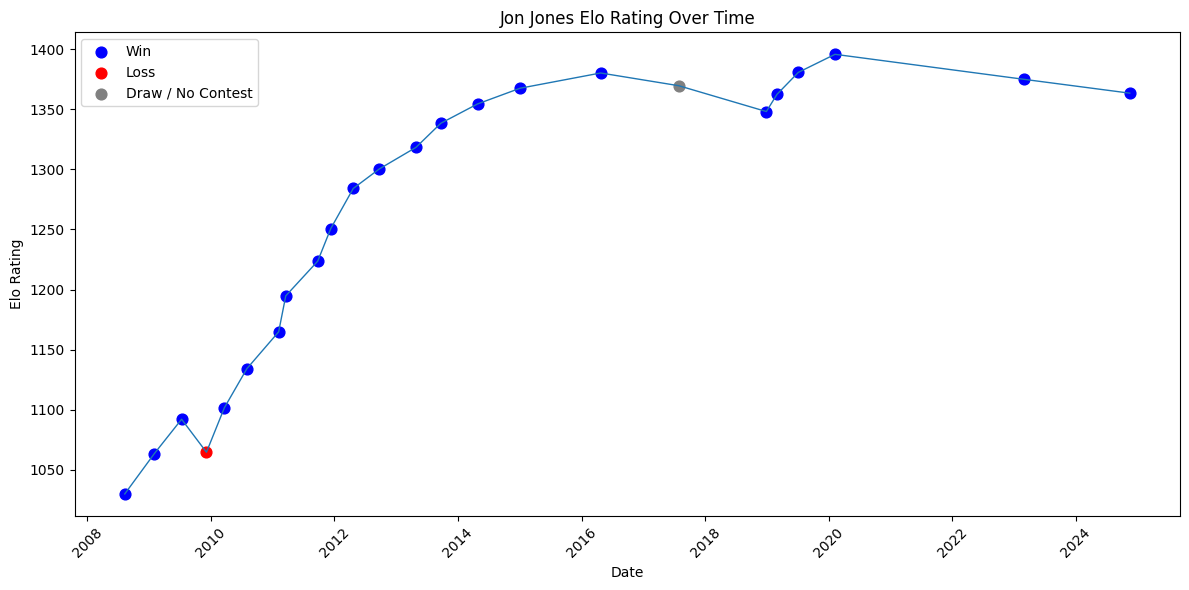

In [ ]:

fighter_name = "Jon Jones"


print(f"Final Elo for {fighter_name}: {round(ratings.get(fighter_name, float('nan')), 2)}")


jon_jones_history = elo_df[
    (elo_df["fighter_a"] == fighter_name) | (elo_df["fighter_b"] == fighter_name)
].copy()


if jon_jones_history.empty:
    print(f"No fights found for {fighter_name}. Check the exact spelling in the dataset.")
else:

    jon_jones_history["elo_before"] = jon_jones_history.apply(
        lambda row: row["fighter_a_before"] if row["fighter_a"] == fighter_name else row["fighter_b_before"],
        axis=1
    )

    jon_jones_history["elo_after"] = jon_jones_history.apply(
        lambda row: row["fighter_a_after"] if row["fighter_a"] == fighter_name else row["fighter_b_after"],
        axis=1
    )


    jon_jones_history["opponent"] = jon_jones_history.apply(
        lambda row: row["fighter_b"] if row["fighter_a"] == fighter_name else row["fighter_a"],
        axis=1
    )


    def fight_outcome(row):
        winner = row["winner"]
        result = str(row["result"]).strip().lower()

        if result == "draw" or pd.isna(winner):
            return "draw/no contest"
        elif winner == fighter_name:
            return "win"
        else:
            return "loss"

    jon_jones_history["outcome"] = jon_jones_history.apply(fight_outcome, axis=1)


    jon_jones_summary = jon_jones_history[
        ["date", "opponent", "winner", "method", "outcome", "elo_before", "elo_after"]
    ].sort_values("date").reset_index(drop=True)

    print("\nJon Jones Elo history:")
    print(jon_jones_summary)

  
    plt.figure(figsize=(12, 6))
    plt.plot(jon_jones_summary["date"], jon_jones_summary["elo_after"], linewidth=1)

    wins = jon_jones_summary[jon_jones_summary["outcome"] == "win"]
    losses = jon_jones_summary[jon_jones_summary["outcome"] == "loss"]
    draws = jon_jones_summary[jon_jones_summary["outcome"] == "draw/no contest"]

    plt.scatter(wins["date"], wins["elo_after"], color="blue", label="Win", s=60)
    plt.scatter(losses["date"], losses["elo_after"], color="red", label="Loss", s=60)
    plt.scatter(draws["date"], draws["elo_after"], color="gray", label="Draw / No Contest", s=60)

    plt.title(f"{fighter_name} Elo Rating Over Time")
    plt.xlabel("Date")
    plt.ylabel("Elo Rating")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

The observed decline in the Elo ratings of certain elite fighters highlights an important characteristic of the model when applied to MMA. Fighters such as Jon Jones, despite their historical dominance may appear with lower ratings in later periods due to reduced activity and extended gaps between fights.

However, this behavior is not necessarily a flaw. Instead, it reflects a different interpretation of what the Elo rating represents. In this implementation, the rating can be understood as an estimate of a fighter’s current competitive level, rather than their historical legacy.

From this perspective, the inactivity decay mechanism plays a crucial role. It ensures that fighters who have not competed for long periods are gradually adjusted downward, reflecting the uncertainty around their present performance level. In a physically demanding sport like MMA, factors such as aging, injuries, and reduced training intensity can significantly impact a fighter’s ability over time.

For example, Georges St-Pierre, one of the greatest fighters in UFC history, retired several years ago. Without an inactivity adjustment, his Elo rating would remain at an elite level with a inactivity_decay = 0.3% (around 1350), potentially placing him among the top-ranked fighters in the current rankings. This would not accurately reflect reality, as at 44 years old and without recent competition, he would likely not be able to compete at the same level as active, younger fighters.

Therefore, maintaining a stronger inactivity decay (e.g., 10%) can be justified when the goal is to model current fighter strength rather than historical greatness. While this approach may penalize legendary fighters in the rankings, it produces a more realistic snapshot of the present competitive landscape.

This highlights an important design choice when applying the Elo system: whether the goal is to measure long-term legacy or current performance. In this project, the model prioritizes current performance, and the inactivity decay is a key component in achieving that.

### Formula 1 
Is it possible to implement an Elo system for a motor sport such as formula 1? The answer is yes, but it requires radical modifications because Formula 1 is not a direct one versus one sport. Instead, multiple drivers compete in the same race, and the final result is an ordered classification from first place to last place. That makes Formula 1 more complex than the sports dscussed earlier, where Elo can be applied more directly.

F1 is the highest level of moter sport, in which ten teams each enters with two drivers across a season of grands prix. In the modern era and especually from the 2000s to 2026 the sport has combined driver skills and engineering brillience.  
Now a similar rating idea has already been explored by the YouTuber "Mr V’s Garage" who created and elo engine and explained a teammate-based version of the model. In his video the formula is the same as the standard one that we also used. But he comeares two drivers from the same team.\Meaning Each driver is only compared to their teammate, treating the the race as a g=head to head contest within the same car. The logic behind his approach is that the teammate comparison reduce the effect of car differences accross the grid, as both driverce race in the same car. 
In this project however, a different version of elo will be used. We'll use a full field elo system.
Instead of comparing a driver only to their teammate each race will be treated as a collection of one versus one comparisons between all drivers.

If Driver A finishes ahead of Driver B, then Driver A is treated as having “won” that mini head-to-head comparison. The total rating update for a driver is then based on how they performed against the entire field, scaled so that one race does not produce excessively large rating changes.

This full-field method allows the model to use the entire finishing order rather than only a single teammate comparison.




In this Formula 1 model, a low K-factor of 10 is used because each race produces many pairwise comparisons between drivers rather than just one direct contest. A larger K would make the rating changes too extreme after a single race. 
Using such low k keeps hte system more stable and better suited to this case.~ 

In [ ]:

starting_elo = 1000
k = 10

elo_history = []

def f1_race(finishing_order, ratings, k, starting_elo, race_name):
    """
    This function applies the Elo system to a full Formula 1 race.
    Instead of treating the race as one single result, each driver is compared against every other driver in the finishing order.

    Parameters:
     - finishing_order: list of drivers in final race order, from 1st to last
     - ratings: dictionary containing current Elo ratings for all drivers
     - k: K-factor used for updating ratings
     - starting_elo: starting rating for new drivers
     - race_name: name of the race, used for tracking the history
    """
    # Assign a starting Elo rating to any driver appearing for the first time
    for driver in finishing_order:
        if driver not in ratings:
            ratings[driver] = starting_elo


    # Create a copy so updates are applied after the full race is processed
    new_ratings = ratings.copy()

    # Number of drivers in the race
    num_drivers = len(finishing_order)

    # Loop through every driver in the finishing order
    for i, driver_a in enumerate(finishing_order):
        rating_a_before = ratings[driver_a]
        total_change = 0

        # Compare this driver against every other driver in the race
        for j, driver_b in enumerate(finishing_order):
            if driver_a == driver_b:
                continue



            rating_b = ratings[driver_b]

            # Expected score of Driver A against Driver B
            expected_a = expected_score(rating_a_before, rating_b)
            # Actual result:
            # Driver A gets 1 if they finished ahead of Driver B,
            # otherwise 0 if they finished behind
            actual_a = 1 if i < j else 0

            # Add the pairwise Elo contribution to the total change
            total_change += (actual_a - expected_a)

         #Scale the total change by the number of comparisons
         # so the rating update does not become too large in a full grid
        rating_a_after = rating_a_before + k * (total_change / (num_drivers - 1))
        new_ratings[driver_a] = rating_a_after

        elo_history.append({
            "race": race_name,
            "driver": driver_a,
            "position": i + 1,
            "rating_before": rating_a_before,
            "rating_after": rating_a_after,
        })

    return new_ratings

In [ ]:
ratings = {}

# Finishing order from the first race
race_1 = [
    "A.K. Antonelli",
    "G. Russell",
    "L. Hamilton",
    "C. Leclerc",
    "O. Bearman",
    "P. Gasly",
    "L. Lawson",
    "I. Hadjar",
    "C. Sainz Jr.",
    "F. Colapinto",
    "N. Hülkenberg",
    "A. Lindblad",
    "V. Bottas",
    "E. Ocon",
    "S. Pérez",
    "M. Verstappen",
    "F. Alonso",
    "L. Stroll",
    "L. Norris",
    "O. Piastri",
    "G. Bortoleto",
    "A. Albon"
]

# Example finishing order from a second race
race_2 = [
    "M. Verstappen",
    "G. Russell",
    "A.K. Antonelli",
    "C. Leclerc",
    "L. Hamilton",
    "C. Sainz Jr.",
    "O. Bearman",
    "P. Gasly",
    "L. Lawson",
    "I. Hadjar",
    "L. Norris",
    "O. Piastri",
    "N. Hülkenberg",
    "A. Albon",
    "F. Colapinto",
    "G. Bortoleto",
    "A. Lindblad",
    "V. Bottas",
    "E. Ocon",
    "S. Pérez",
    "F. Alonso",
    "L. Stroll",
]
# Process both races in chronological order
ratings = f1_race(race_1, ratings, k, starting_elo, "Race 1")
ratings = f1_race(race_2, ratings, k, starting_elo, "Race 2")


elo_df = pd.DataFrame(elo_history).round(2)

print(elo_df)
print()

# Let's see the top drivers by their final Elo ratings
print("Top drivers by elo:")
top_drivers = pd.DataFrame(ratings.items(), columns=["driver", "elo"]).sort_values("elo", ascending=False)
print(top_drivers.round(2))

      race          driver  position  rating_before  rating_after
0   Race 1  A.K. Antonelli         1        1000.00       1005.00
1   Race 1      G. Russell         2        1000.00       1004.52
2   Race 1     L. Hamilton         3        1000.00       1004.05
3   Race 1      C. Leclerc         4        1000.00       1003.57
4   Race 1      O. Bearman         5        1000.00       1003.10
5   Race 1        P. Gasly         6        1000.00       1002.62
6   Race 1       L. Lawson         7        1000.00       1002.14
7   Race 1       I. Hadjar         8        1000.00       1001.67
8   Race 1    C. Sainz Jr.         9        1000.00       1001.19
9   Race 1    F. Colapinto        10        1000.00       1000.71
10  Race 1   N. Hülkenberg        11        1000.00       1000.24
11  Race 1     A. Lindblad        12        1000.00        999.76
12  Race 1       V. Bottas        13        1000.00        999.29
13  Race 1         E. Ocon        14        1000.00        998.81
14  Race 1

THe problem with this approach is that
Car performance heavily distorts the rating, this is a huge problem as one driver might be better than another but the car of the weaker driver migh be better. Meaning we measure driver + car and not the pure driver skill.

## 7. Conclusions

In this project, we explored how the Elo rating system can be applied across a variety of competitive environments, including chess, MMA, football, esports, and Formula 1.

We began with the standard Elo model, which provides a simple yet powerful framework for estimating skill based on match outcomes and opponent strength. Through this foundation, it became clear that while Elo works perfectly in structured one-versus-one environments like chess, real-world applications often require adaptations.

Each sport introduced unique challenges:
- Chess demonstrated the ideal use case of Elo, where the system functions exactly as intended.
- MMA highlighted the importance of adjusting the K-factor due to infrequent matches and introduced the idea of incorporating the method of victory.
- Football showed how team-based competition and frequent matches require more stable updates, with possible extensions such as goal difference.
- Counter-Strike illustrated the distinction between team ranking and individual performance, emphasizing the limitations of Elo for player-level evaluation.
- Formula 1 presented the most complex scenario, requiring a full-field approach and revealing the difficulty of separating individual skill from external factors such as car performance.

By introducing small modifications—such as K-factor adjustments and performance-based multipliers—we were able to make the model more expressive while preserving its core logic.

At the same time, the project also highlighted important limitations. Elo does not account for contextual factors such as in-game performance, team dynamics, or external influences. In more complex environments, more advanced models may be required to fully capture performance.

Overall this project demonstrates that Elo is can be used not only as a chess rating system, but a flexible framework that can be extended to many domains. With thoughtful adjustments, it can provide meaningful insights into competitive performance across a wide range of sports.

# Sources
Video - The Elo Rating System for Chess and Beyond
https://www.youtube.com/watch?v=AsYfbmp0To0

FIDE - Calculators for Chess Rating
https://ratings.fide.com/calc.phtml?page=change

Chess Chess rating system:
https://en.wikipedia.org/wiki/Chess_rating_system

UFC Fights - Data Set
https://www.kaggle.com/datasets/trixster23/every-ufc-fight-ever?resource=download

WhoScored
https://www.whoscored.com/explanations

Sofascore
https://corporate.sofascore.com/about/rating

HLTV
https://www.hltv.org/news/40051/introducing-rating-21

Counter-strike Rules and Regulations GitHub
https://github.com/ValveSoftware/counter-strike_rules_and_regs

Mr V's Garage Video - "I made an F1 ELO Engine. Who's highest rated?"
https://www.youtube.com/watch?v=U16a8tdrbII

